# Senegal Power Plant Data Comparison

Comparing two power plant datasets for Senegal:

1. **`powerplants.csv`** — a plant-level dataset in the PyPSA-Earth / `powerplantmatching` style,
   built from Global Energy Monitor (GEM) and WRI Global Power Plant Database (GPD) matching.
2. **`Supplementary-Data-1_INVENTORY.xlsx`** — a unit-level plant inventory with additional
   cooling-water and carbon-emissions attributes (`Main_Inventory` sheet, filtered to Senegal).

The goal is to reconcile the two sources — checking total capacity, fuel-type classification,
plant counts, and individual-site matches — before using either as a model input.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)


## 1. Load the data

In [6]:
# Dataset 1: powerplants.csv (PyPSA-Earth / powerplantmatching style)
pp = pd.read_csv('resources/powerplants.csv', index_col=0)
print(f"powerplants.csv: {len(pp)} units, {pp['Capacity'].sum():,.1f} MW total")
pp.head()


powerplants.csv: 34 units, 2,178.3 MW total


,Name,Fueltype,Technology,Set,Country,Capacity,Efficiency,Duration,Volume_Mm3,DamHeight_m,StorageCapacity_MWh,DateIn,DateRetrofit,DateOut,lat,lon,EIC,projectID,bus,region_id
0,Bokhol Solar Farm,Solar,PV,PP,SN,20.0,NaN,NaN,NaN,NaN,NaN,2016.0,2016.0,2041.0,16.5172,-15.4692,{nan},"{'GEM': {'G100000800081'}, 'GPD': {'WKS0067471'}}",12,SN.10_1
1,Kahone Solaire Sa Solar Farm,Solar,PV,PP,SN,60.0,NaN,NaN,NaN,NaN,NaN,2017.0,2017.0,2042.0,14.1735,-16.0260,"{nan, nan}","{'GEM': {'G100000800192', 'G100000800191'}, 'G...",19,SN.5_1
2,Ten Merina Solar Farm,Solar,PV,PP,SN,30.0,NaN,NaN,NaN,NaN,NaN,2018.0,2018.0,2043.0,15.1301,-16.6760,{nan},"{'GEM': {'G100000800396'}, 'GPD': {'WKS0067472'}}",7,SN.13_1
3,Bel Air,Oil,NaN,PP,SN,98.6,NaN,NaN,NaN,NaN,NaN,2008.5,2008.5,2048.5,14.7170,-17.4780,{nan},{'GPD': {'WRI1023157'}},6,SN.1_1
4,Boutoute,Oil,NaN,PP,SN,19.0,NaN,NaN,NaN,NaN,NaN,2008.5,2008.5,2048.5,12.5819,-16.2782,{nan},{'GPD': {'WRI1023162'}},24,SN.14_1


In [7]:
# Dataset 2: Supplementary inventory, filtered to Senegal
inv_full = pd.read_excel('extra_resources/Supplementary-Data-1_INVENTORY.xlsx', sheet_name='Main_Inventory')
inv = inv_full[inv_full['Country'] == 'SENEGAL'].copy()
print(f"Inventory (Senegal): {len(inv)} units, {inv['MW'].sum():,.1f} MW total")
inv.head()


Inventory (Senegal): 76 units, 2,133.1 MW total


,ID_Number,Country,Plant,Operation Year,MW,MWh/MW,MWh,GEN_TYPE,Operation,Infrastructure,Cooling System,Cooling Fluid,Specific Fuel,Climate,Withdrawal [m3],Consumption [m3],Carbon [tCO2e],Longitude,Latitude,details
2223,44001,SENEGAL,BAKEL,2020,0.921,3795.45,3495.60945,Oil,ICE,Diesel-Engines,Dry cooling,Air,Diesel,NaN,1132.576556,792.803589,2936.311938,-12.459351,14.902377,"By the size and fuel, it must be a small MCI g..."
2224,44002,SENEGAL,BANDAFASSI,2020,0.025,3795.45,94.88625,Oil,ICE,Diesel-Engines,Dry cooling,Air,Diesel,NaN,30.743120,21.520184,79.704450,-12.310616,12.538844,By its size and fuel I assume it is an ICE wit...
2225,44003,SENEGAL,BASSOUL BASSAR,2020,0.965,3795.45,3662.60925,Oil,ICE,Diesel-Engines,Dry cooling,Air,Diesel,NaN,1186.684448,830.679113,3076.591770,-16.607730,13.919113,"By the size and fuel, it must be a small MCI g..."
2226,44004,SENEGAL,BEL-AIR,2020,66.850,3795.45,253725.83250,Oil,ICE,Diesel-Engines,Dry cooling,Air,HFO,NaN,82207.103964,57544.972775,213129.699300,-17.434595,14.690360,"Diesel engines, https://fr.wikipedia.org/wiki/..."
2227,44005,SENEGAL,BEL-AIR C6,2020,66.850,3795.45,253725.83250,Oil,ICE,Diesel-Engines,Dry cooling,Air,HFO,NaN,82207.103964,57544.972775,213129.699300,-17.434169,14.690706,"Diesel engines, likely with HFO"


## 2. Headline totals

Total installed capacity should be similar even if the two sources structure
their data very differently.

In [8]:
summary = pd.DataFrame({
    'powerplants.csv': [len(pp), pp['Capacity'].sum()],
    'Inventory (Senegal)': [len(inv), inv['MW'].sum()],
}, index=['Number of units', 'Total capacity (MW)'])
summary


,powerplants.csv,Inventory (Senegal)
Number of units,34.00,76.000
Total capacity (MW),2178.26,2133.108


## 3. Capacity by fuel / generation type

The two datasets use different labels for fuel type (`Fueltype` vs `GEN_TYPE`).
We compare them side by side without trying to force a common taxonomy yet,
so the mismatches themselves are visible.

In [9]:
pp_by_fuel = pp.groupby('Fueltype')['Capacity'].agg(['count', 'sum']).sort_values('sum', ascending=False)
pp_by_fuel.columns = ['pp_count', 'pp_MW']

inv_by_fuel = inv.groupby('GEN_TYPE')['MW'].agg(['count', 'sum']).sort_values('sum', ascending=False)
inv_by_fuel.columns = ['inv_count', 'inv_MW']

pp_by_fuel


,pp_count,pp_MW
Fueltype,,
CCGT,5,646.00
Oil,8,608.96
Solar,15,400.30
Wind,2,208.00
Hard Coal,2,155.00
Hydro,1,120.00
Solid Biomass,1,40.00


In [10]:
inv_by_fuel


,inv_count,inv_MW
GEN_TYPE,,
Oil,55,771.404
Hydropower,1,402.000
NG,2,386.000
Coal,3,185.000
Sun,10,182.804
Wind,2,158.700
Biomass,1,25.000
waste heat,2,22.200


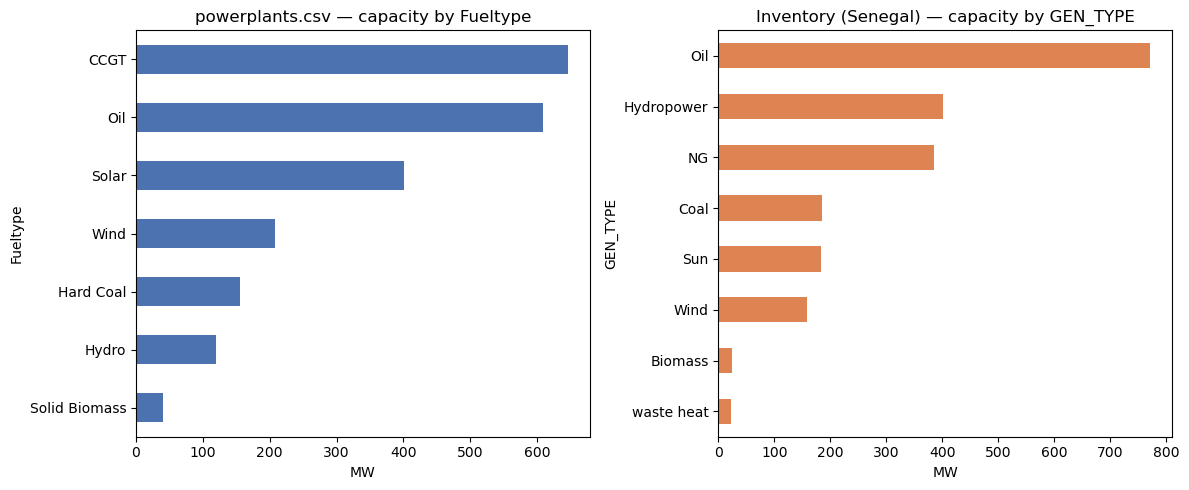

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

pp_by_fuel['pp_MW'].sort_values().plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('powerplants.csv — capacity by Fueltype')
axes[0].set_xlabel('MW')

inv_by_fuel['inv_MW'].sort_values().plot(kind='barh', ax=axes[1], color='#DD8452')
axes[1].set_title('Inventory (Senegal) — capacity by GEN_TYPE')
axes[1].set_xlabel('MW')

plt.tight_layout()
plt.show()


## 4. Why does the inventory have so many more units?

`powerplants.csv` has 34 units; the inventory has 76. Let's check whether this
is driven by many small captive/off-grid units that the GEM/WRI-matched
`powerplants.csv` simply doesn't track.

In [12]:
threshold = 5  # MW
small = inv[inv['MW'] < threshold]
big = inv[inv['MW'] >= threshold]

print(f"Inventory units < {threshold} MW: {len(small)}  (total {small['MW'].sum():,.1f} MW)")
print(f"Inventory units >= {threshold} MW: {len(big)}  (total {big['MW'].sum():,.1f} MW)")
print(f"\npowerplants.csv smallest unit: {pp['Capacity'].min()} MW")


Inventory units < 5 MW: 41  (total 34.2 MW)
Inventory units >= 5 MW: 35  (total 2,098.9 MW)

powerplants.csv smallest unit: 3.6 MW


**Takeaway:** most of the extra 40+ inventory entries are small captive
diesel generators (rural sites, hospitals, cement plants, gold mines) well
under 5 MW each. Together they add up to only a couple of percent of total
capacity — the *unit count* gap is mostly a coverage-threshold artifact, not
a capacity disagreement.

## 5. Matching individual plants by location

Names differ between sources (e.g. "Cap Des Biches" vs "CAP-DES-BICHES C1"),
so we match by nearest geographic coordinates instead of by name.

In [13]:
def haversine_km(lat1, lon1, lat2, lon2):
    # simple approx good enough for country-scale distances
    return np.sqrt((lat1 - lat2) ** 2 + (lon1 - lon2) ** 2) * 111

inv_geo = inv.dropna(subset=['Latitude', 'Longitude']).copy()

matches = []
for idx, prow in pp.iterrows():
    d = haversine_km(prow['lat'], prow['lon'], inv_geo['Latitude'], inv_geo['Longitude'])
    nearest_idx = d.idxmin()
    nearest = inv_geo.loc[nearest_idx]
    matches.append({
        'pp_name': prow['Name'],
        'pp_MW': prow['Capacity'],
        'pp_fuel': prow['Fueltype'],
        'distance_km': round(d.loc[nearest_idx], 2),
        'inv_name': nearest['Plant'],
        'inv_MW': nearest['MW'],
        'inv_fuel': nearest['GEN_TYPE'],
    })

match_df = pd.DataFrame(matches).sort_values('distance_km')
match_df


,pp_name,pp_MW,pp_fuel,distance_km,inv_name,inv_MW,inv_fuel
0,Bokhol Solar Farm,20.00,Solar,0.00,SAINT-LOUIS Bokhol solar park,20.000,Sun
30,Sendou Timepoint,125.00,Hard Coal,0.00,SENDOU,125.000,Coal
32,Taiba Diaye Wind Farm,158.00,Wind,0.00,TAIBA NDIAYE,55.200,Wind
9,Sambangalou,120.00,Hydro,0.00,SAMBANGALOU,402.000,Hydropower
8,Saint Louis,10.50,Oil,0.00,SAINT-LOUIS,6.500,Oil
16,Gallen Cement,30.00,Hard Coal,0.00,GALLEN CEMENT,30.000,Coal
33,Tobene,115.00,CCGT,0.00,TOBENE (Taiba Ndiaye),111.000,Oil
2,Ten Merina Solar Farm,30.00,Solar,0.02,SANTHIOU-MEKHE,30.000,Sun
19,Kounoune,67.50,Oil,0.02,KOUNOUNE-I,67.500,Oil
10,Bel Air,90.00,CCGT,0.03,BEL-AIR C6,66.850,Oil


Rows with `distance_km` near 0 are almost certainly the same physical site.
Larger distances mean the nearest inventory entry probably isn't a true match
(that plant may simply be missing from one of the two sources, or the
coordinates in one source contain an error).

In [14]:
# Flag likely true matches (same site) vs. likely no-match
match_df['likely_same_site'] = match_df['distance_km'] < 2
match_df


,pp_name,pp_MW,pp_fuel,distance_km,inv_name,inv_MW,inv_fuel,likely_same_site
0,Bokhol Solar Farm,20.00,Solar,0.00,SAINT-LOUIS Bokhol solar park,20.000,Sun,True
30,Sendou Timepoint,125.00,Hard Coal,0.00,SENDOU,125.000,Coal,True
32,Taiba Diaye Wind Farm,158.00,Wind,0.00,TAIBA NDIAYE,55.200,Wind,True
9,Sambangalou,120.00,Hydro,0.00,SAMBANGALOU,402.000,Hydropower,True
8,Saint Louis,10.50,Oil,0.00,SAINT-LOUIS,6.500,Oil,True
16,Gallen Cement,30.00,Hard Coal,0.00,GALLEN CEMENT,30.000,Coal,True
33,Tobene,115.00,CCGT,0.00,TOBENE (Taiba Ndiaye),111.000,Oil,True
2,Ten Merina Solar Farm,30.00,Solar,0.02,SANTHIOU-MEKHE,30.000,Sun,True
19,Kounoune,67.50,Oil,0.02,KOUNOUNE-I,67.500,Oil,True
10,Bel Air,90.00,CCGT,0.03,BEL-AIR C6,66.850,Oil,True


## 6. Specific discrepancies worth flagging

### 6.1 Coordinate error check
Senegal's latitude range is roughly 12°N–17°N and longitude roughly 11°W–18°W.
Any plant outside that box likely has a data entry error.

In [15]:
lat_min, lat_max = 12.0, 17.0
lon_min, lon_max = -18.0, -11.0

pp_out_of_bounds = pp[~pp['lat'].between(lat_min, lat_max) | ~pp['lon'].between(lon_min, lon_max)]
inv_out_of_bounds = inv_geo[~inv_geo['Latitude'].between(lat_min, lat_max) | ~inv_geo['Longitude'].between(lon_min, lon_max)]

print("Out-of-bounds coordinates in powerplants.csv:")
display(pp_out_of_bounds[['Name', 'Fueltype', 'Capacity', 'lat', 'lon']])

print("\nOut-of-bounds coordinates in inventory:")
display(inv_out_of_bounds[['Plant', 'GEN_TYPE', 'MW', 'Latitude', 'Longitude']])


Out-of-bounds coordinates in powerplants.csv:


,Name,Fueltype,Capacity,lat,lon
5,Cap Des Biches,Oil,327.0,17.7197,-17.2996



Out-of-bounds coordinates in inventory:


,Plant,GEN_TYPE,MW,Latitude,Longitude


### 6.2 CCGT vs. Oil classification

`powerplants.csv` labels several plants as `CCGT` by design/technology,
while the inventory classifies the same sites as running on `Oil` (HFO) —
consistent with Senegal's gas-to-power transition still being in progress.

In [16]:
ccgt_plants = pp[pp['Fueltype'] == 'CCGT']
ccgt_plants[['Name', 'Capacity', 'lat', 'lon']]


,Name,Capacity,lat,lon
10,Bel Air,90.0,14.690486,-17.434005
11,Cap Des Biches Engine,86.0,14.718988,-17.297044
18,Karpowership Senegal Aysegul Sultan,235.0,14.689333,-17.432331
22,Malicounda,120.0,14.472403,-16.950748
33,Tobene,115.0,15.007438,-16.861741


In [17]:
# Cross-check each CCGT-labelled plant against its nearest inventory match
ccgt_check = match_df[match_df['pp_fuel'] == 'CCGT']
ccgt_check


,pp_name,pp_MW,pp_fuel,distance_km,inv_name,inv_MW,inv_fuel,likely_same_site
33,Tobene,115.0,CCGT,0.00,TOBENE (Taiba Ndiaye),111.00,Oil,True
10,Bel Air,90.0,CCGT,0.03,BEL-AIR C6,66.85,Oil,True
11,Cap Des Biches Engine,86.0,CCGT,0.21,CAP DES BICHES C1,53.01,Oil,True
18,Karpowership Senegal Aysegul Sultan,235.0,CCGT,0.25,BEL-AIR C6,66.85,Oil,True
22,Malicounda,120.0,CCGT,15.22,Diass power station,23.00,Sun,False


### 6.3 Sambangalou hydro capacity

Same site, very different reported capacity — worth confirming which
vintage/assumption is appropriate for the model.

In [18]:
display(pp[pp['Name'].str.contains('Sambangalou', case=False)][['Name', 'Fueltype', 'Capacity', 'DateIn']])
display(inv[inv['Plant'].str.contains('SAMBANGALOU', case=False)][['Plant', 'GEN_TYPE', 'MW', 'Operation Year']])


,Name,Fueltype,Capacity,DateIn
9,Sambangalou,Hydro,120.0,2016.273438


,Plant,GEN_TYPE,MW,Operation Year
2296,SAMBANGALOU,Hydropower,402.0,2025


### 6.4 Solar capacity gap

`powerplants.csv` reports substantially more solar capacity than the
inventory. Let's see which solar farms in `powerplants.csv` have no
close geographic match in the inventory (`distance_km` is large).

In [19]:
solar_check = match_df[match_df['pp_fuel'] == 'Solar'].sort_values('distance_km', ascending=False)
solar_check


,pp_name,pp_MW,pp_fuel,distance_km,inv_name,inv_MW,inv_fuel,likely_same_site
17,Kael Solar Farm,35.0,Solar,36.41,DIOURBEL PLANT,4.300,Oil,False
31,Senegal Solar,8.3,Solar,33.53,RICHARD TOLL,0.511,Oil,False
28,Sakal Solar Farm,20.0,Solar,30.50,SAKAL,20.000,Sun,False
24,Nea Kolda Solar Farm,60.0,Solar,21.10,SEDHIOU,0.947,Oil,False
23,Malicounda Solar Farm,22.0,Solar,16.37,N'DOLLOR CLINIC,0.004,Sun,False
15,Diass Solar Farm,23.0,Solar,9.80,KIRENE CEMENT PLANT,50.000,Oil,False
13,Dakar Region Solar,7.8,Solar,1.86,SENDOU,125.000,Coal,True
25,Rufisque Solar,9.2,Solar,1.50,SOCOCIM CEMENT PLANT,24.000,Oil,True
26,Sabodala Massawa Mine Solar Farm,37.0,Solar,1.21,SABODALA GOLD MINE,36.000,Oil,True
14,Dakar Region Solar,3.6,Solar,0.81,CENTRE CONF DIAMNIADIO,2.000,Sun,True


## 7. Reconciled summary table

A side-by-side reconciliation by broad category, grouping `CCGT`/`NG`/`Oil`
together as "thermal (oil/gas)" so the comparison isn't distorted by the
labelling difference described above.

In [20]:
def bucket_pp(fuel):
    if fuel in ('CCGT', 'Oil'):
        return 'Thermal (oil/gas)'
    if fuel == 'Hard Coal':
        return 'Coal'
    if fuel == 'Solid Biomass':
        return 'Biomass'
    return fuel  # Solar, Wind, Hydro

def bucket_inv(fuel):
    if fuel in ('Oil', 'NG', 'waste heat'):
        return 'Thermal (oil/gas)'
    if fuel == 'Coal':
        return 'Coal'
    if fuel == 'Biomass':
        return 'Biomass'
    if fuel == 'Sun':
        return 'Solar'
    if fuel == 'Hydropower':
        return 'Hydro'
    return fuel

pp_b = pp.copy()
pp_b['bucket'] = pp_b['Fueltype'].apply(bucket_pp)
inv_b = inv.copy()
inv_b['bucket'] = inv_b['GEN_TYPE'].apply(bucket_inv)

recon = pd.concat([
    pp_b.groupby('bucket')['Capacity'].sum().rename('powerplants.csv (MW)'),
    inv_b.groupby('bucket')['MW'].sum().rename('Inventory (MW)'),
], axis=1).fillna(0)

recon['Difference (MW)'] = recon['powerplants.csv (MW)'] - recon['Inventory (MW)']
recon['Difference (%)'] = (recon['Difference (MW)'] / recon['Inventory (MW)'] * 100).round(1)
recon.loc['TOTAL'] = recon.sum()
recon


,powerplants.csv (MW),Inventory (MW),Difference (MW),Difference (%)
bucket,,,,
Biomass,40.00,25.000,15.000,60.0
Coal,155.00,185.000,-30.000,-16.2
Hydro,120.00,402.000,-282.000,-70.1
Solar,400.30,182.804,217.496,119.0
Thermal (oil/gas),1254.96,1179.604,75.356,6.4
Wind,208.00,158.700,49.300,31.1
TOTAL,2178.26,2133.108,45.152,130.2


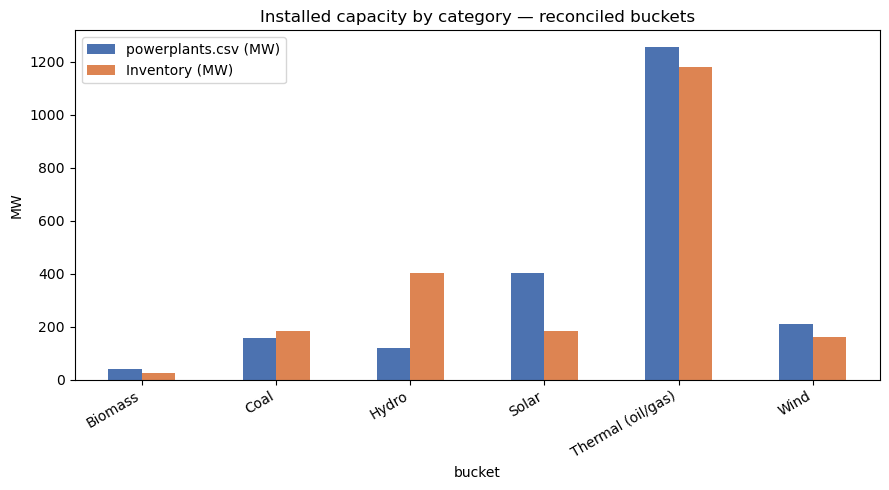

In [21]:
recon.iloc[:-1][['powerplants.csv (MW)', 'Inventory (MW)']].plot(
    kind='bar', figsize=(9, 5), color=['#4C72B0', '#DD8452']
)
plt.ylabel('MW')
plt.title('Installed capacity by category — reconciled buckets')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 8. Save reconciliation outputs

Write the matched-plant table and the bucketed reconciliation table to CSV
for use elsewhere (e.g. as a cross-check input for the PyPSA-Earth model).

In [22]:
match_df.to_csv('plant_matches.csv', index=False)
recon.to_csv('capacity_reconciliation.csv')
print("Saved: plant_matches.csv, capacity_reconciliation.csv")


Saved: plant_matches.csv, capacity_reconciliation.csv


## 9. Summary of findings

- **Total capacity is close**: 2,178 MW (`powerplants.csv`) vs. 2,133 MW (inventory) — within ~2%.
- **Unit count differs a lot** (34 vs. 76), but the gap is mostly small captive diesel
  generators in the inventory (<5 MW each, together only a couple of percent of total capacity).
- **CCGT vs. Oil labelling**: `powerplants.csv` tags ~650 MW as `CCGT` by design; the inventory
  shows most of that capacity is still run as `Oil` (HFO), reflecting Senegal's ongoing
  gas-to-power transition rather than a data error.
- **Sambangalou hydro**: 120 MW vs. 402 MW at the same site — check which capacity
  vintage/assumption is intended before using either figure.
- **Coordinate error**: `powerplants.csv`'s "Cap Des Biches" (327 MW) has a latitude
  (17.72°N) outside Senegal's bounds — likely a transposed-digit typo (probably 14.72°N).
- **Solar gap**: `powerplants.csv` reports more solar capacity overall; several 2019–2023
  solar farms present in `powerplants.csv` have no close-distance match in the inventory,
  suggesting the inventory's non-thermal coverage has an earlier effective cutoff.


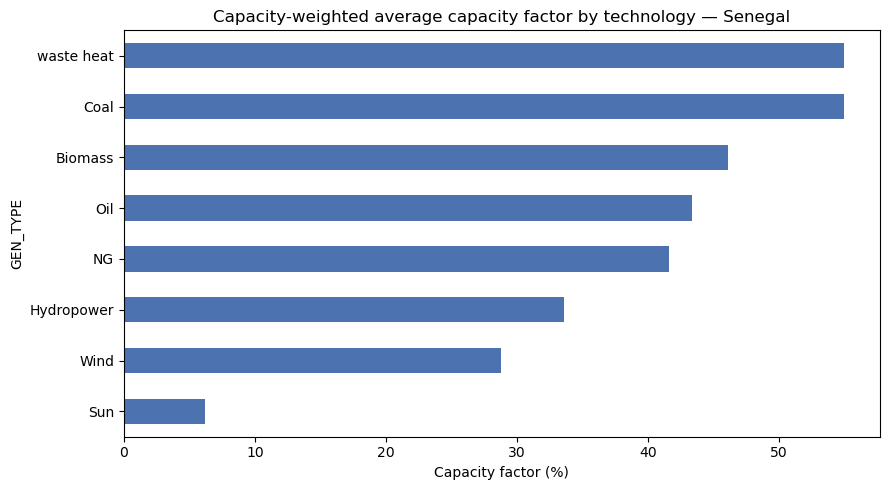

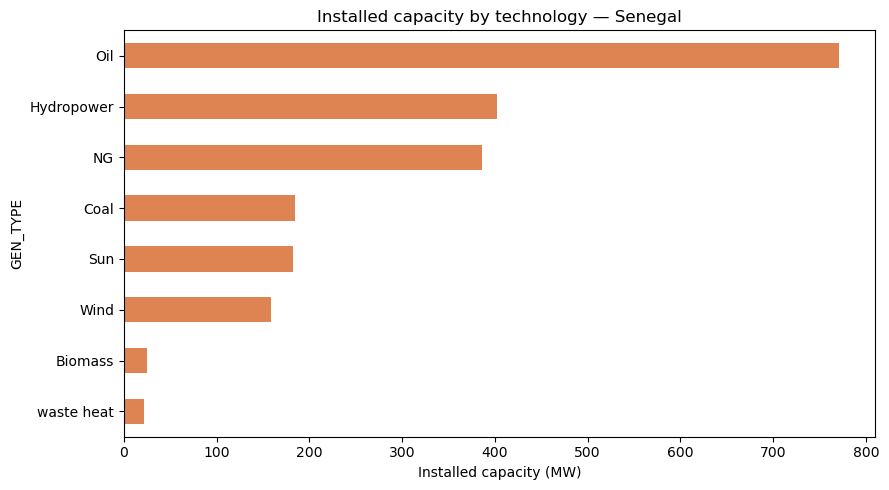

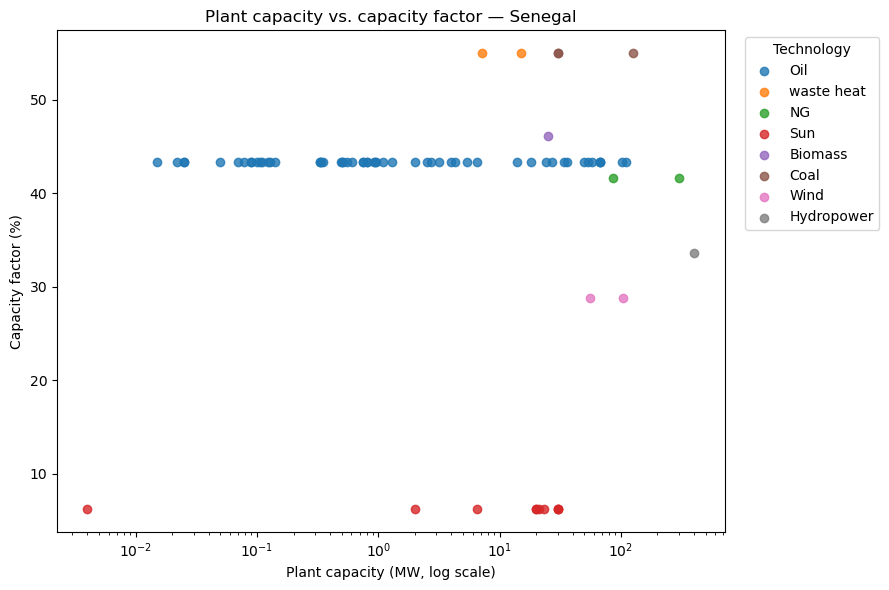

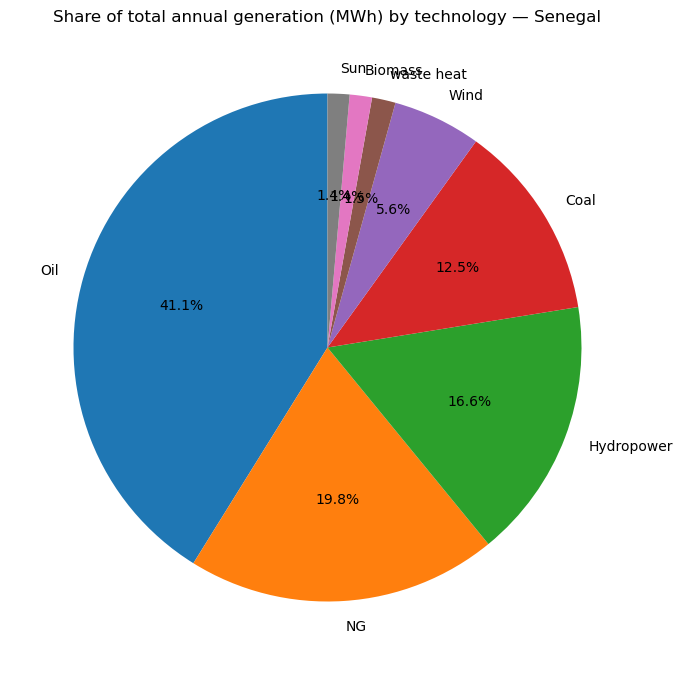

In [28]:

"""
Plots for Senegal capacity factors from the Supplementary Data 1 inventory.
 
Assumes senegal_capacity_factor.py's calculation logic - reproduced here so
this file can run standalone.
"""
 
import pandas as pd
import matplotlib.pyplot as plt
 
HOURS_PER_YEAR = 8760
INPUT_FILE = "extra_resources/Supplementary-Data-1_INVENTORY.xlsx"
SHEET_NAME = "Main_Inventory"
 
# --- Load, filter, calculate CF ---------------------------------------------
df = pd.read_excel(INPUT_FILE, sheet_name=SHEET_NAME)
df = df[df["Country"] == "SENEGAL"].copy()
df = df[df["MW"] > 0].copy()
df["capacity_factor_pct"] = (df["MWh"] / (df["MW"] * HOURS_PER_YEAR)) * 100
 
summary = df.groupby("GEN_TYPE").agg(
    n_plants=("MW", "count"),
    total_MW=("MW", "sum"),
    total_MWh=("MWh", "sum"),
)
summary["weighted_cf_pct"] = summary["total_MWh"] / (summary["total_MW"] * HOURS_PER_YEAR) * 100
summary = summary.sort_values("weighted_cf_pct", ascending=False)
 
# --- Plot 1: capacity-weighted CF by technology -----------------------------
fig1, ax1 = plt.subplots(figsize=(9, 5))
summary["weighted_cf_pct"].sort_values().plot(kind="barh", ax=ax1, color="#4C72B0")
ax1.set_xlabel("Capacity factor (%)")
ax1.set_title("Capacity-weighted average capacity factor by technology — Senegal")
plt.tight_layout()
 
# --- Plot 2: installed capacity (MW) by technology --------------------------
fig2, ax2 = plt.subplots(figsize=(9, 5))
summary["total_MW"].sort_values().plot(kind="barh", ax=ax2, color="#DD8452")
ax2.set_xlabel("Installed capacity (MW)")
ax2.set_title("Installed capacity by technology — Senegal")
plt.tight_layout()
 
# --- Plot 3: per-plant capacity vs. capacity factor, colored by technology --
fig3, ax3 = plt.subplots(figsize=(9, 6))
technologies = df["GEN_TYPE"].unique()
colors = plt.cm.tab10.colors
for tech, color in zip(technologies, colors):
    subset = df[df["GEN_TYPE"] == tech]
    ax3.scatter(subset["MW"], subset["capacity_factor_pct"], label=tech, color=color, alpha=0.8)
ax3.set_xscale("log")
ax3.set_xlabel("Plant capacity (MW, log scale)")
ax3.set_ylabel("Capacity factor (%)")
ax3.set_title("Plant capacity vs. capacity factor — Senegal")
ax3.legend(title="Technology", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
 
# --- Plot 4: generation mix (MWh share) by technology, pie chart ------------
fig4, ax4 = plt.subplots(figsize=(7, 7))
summary["total_MWh"].sort_values(ascending=False).plot(
    kind="pie", ax=ax4, autopct="%1.1f%%", ylabel="", startangle=90
)
ax4.set_title("Share of total annual generation (MWh) by technology — Senegal")
plt.tight_layout()
 
plt.show()
 